In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import json
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.sequential as SEQUENTIAL

import nomad.visit_attribution.visit_attribution as visits

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics
import warnings
warnings.filterwarnings('ignore', message='Input is timezone-naive; assuming UTC')

In [2]:
def _desaturate_toward_white(color, amount=0.5):
    """
    amount=0 → original color
    amount=1 → white
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(rgb + (white - rgb) * amount)

def plot_metric_vs_param(
    ax,
    data,
    x,
    y,
    algo_param,
    show_max_mean_line=False,
    title="",
    xlabel="",
    ylabel="",
    *,
    fontsize=15,
    color_idx=0,
    cmap="tab10",
    show_band=False,
):
    """
    Plot y vs x on a provided Axes with raw points (on top),
    mean line, optional mean ± std band, and optional max-mean line.
    """

    stats = (
        data.groupby(algo_param)[y]
        .agg(mean="mean", std="std")
        .reset_index()
        .sort_values(algo_param)
    )

    stats_by_user = (
        data.loc[data.groupby('user_id')[y].idxmax(), ['user_id', y, algo_param]]
        .reset_index(drop=True)
    )

    # Pick a base color from a colormap by index
    base = plt.get_cmap(cmap)(color_idx % plt.get_cmap(cmap).N)

    # Draw band first so everything else is above it
    if show_band:
        ax.fill_between(
            stats[algo_param],
            stats["mean"] - stats["std"],
            stats["mean"] + stats["std"],
            color=base,
            alpha=0.22,
            label="Mean ± 1 SD",
            zorder=1,
        )

    # Raw points (ensure it's above the band)
    scatter_color = _desaturate_toward_white(base, amount=0.4)
    sns.scatterplot(
        data=data,
        x=x,
        y=y,
        alpha=0.07,
        s=35,
        ax=ax,
        legend=False,
        color=scatter_color,
        zorder=3,
    )

    # Mean line
    ax.plot(
        stats[algo_param],
        stats["mean"],
        linewidth=3,
        color=base,
        label="Mean",
        zorder=4,
    )

    # Per user max point
    ax.scatter(
        stats_by_user[algo_param],
        stats_by_user[y],
        color='red',
        s=20,
        alpha=0.6,
        marker='x',
        linewidths=1,
        label="User maxima",
        zorder=6
    )

    # Optional max-mean horizontal line
    if show_max_mean_line:
        max_mean = float(np.nanmax(stats["mean"].to_numpy()))
        ax.axhline(
            max_mean,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Max mean ({max_mean:.3g})",
            zorder=5,
        )

        mean_max = stats_by_user[y].mean()
        ax.axhline(
            mean_max,
            color="red",
            linestyle=":",
            linewidth=1.5,
            label=f"Mean of user maxima ({mean_max:.3g})",
            zorder=5,
        )

    # Text styling
    ax.set_title(title, fontsize=fontsize + 2)
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.tick_params(axis="both", labelsize=fontsize - 2)

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="best", frameon=True, fontsize=fontsize - 2)

    return ax

## Load Files

In [3]:
with open('config_beta_8_5.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [4]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
sparse_df.drop(columns=['datetime'], inplace=True)

diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

In [ ]:
delta_roam_values = np.linspace(5, 60, 100)

config["algos"] = {
    **{f"lachesis_delta_{int(dr)}": {
        "func": LACHESIS.lachesis_labels,
        "params": {
            'dt_max': 60,
            'delta_roam': 1.7*dr
        },
        "visit_attr":"majority"
    } for dr in delta_roam_values},
    **{f"sequential_delta_{int(dr)}": {
        "func": SEQUENTIAL.detect_stops_labels,
        "params": {
            'dt_max': 60,
            'delta_roam': dr,
            'method':'centroid'
        },
        "visit_attr":"majority"
    } for dr in delta_roam_values}
}

summarize_stops_with_loc = partial(
    utils.summarize_stop,
    x='x',
    y='y',
    timestamp='timestamp',
    keep_col_names=True,
    passthrough_cols=['location'],
    complete_output=False)

In [6]:
results_list = []
sparse_df['precomp_locations'] = visits.poi_map(
    sparse_df,
    poi_table=poi_table.loc[poi_table.location.isin(['w-x17-y10', 'r-x19-y11'])],
    data_crs='EPSG:3857',
    max_distance=20, 
    location_id='location',
    x='x',
    y='y'
)

for user in tqdm(diaries_df.user_id.unique(), desc='Processing users'):
    sparse = sparse_df.query("user_id==@user").copy()
    truth = diaries_df.query("user_id==@user").copy()
    
    # Run all st-dbscan parameterizations
    for algo_name, algo_config in config["algos"].items():
        # Run stop detection
        labels = algo_config["func"](sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        sparse['cluster'] = labels
        sparse['location'] = sparse['precomp_locations']
        
        # Map stops to buildings
        sparse["location"] = visits.point_in_polygon(
            sparse, 
            poi_table=poi_table.loc[poi_table.location.isin(['w-x17-y10', 'r-x19-y11'])],
            data_crs='EPSG:3857',
            max_distance=20, 
            location_id='location', 
            method=algo_config["visit_attr"],
            x='x', 
            y='y',
            recompute_location=False
        )

        stops = sparse[sparse.cluster!=-1].groupby('cluster', as_index=False).apply(
            summarize_stops_with_loc, include_groups=False) # no need to deal with empty case
        
        # Compute metrics
        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo_name,
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
        
        # Add delta_roam value to metrics
        metrics['delta_roam'] = algo_config['params']['delta_roam']
        
        results_list.append(metrics)
        # Clean up temporary columns for next iteration
        sparse.drop(columns=['cluster', 'location'], inplace=True)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"Computed metrics for {len(results_df)} user-algorithm combinations")
print(f"Number of unique delta_roam values: {results_df['delta_roam'].nunique()}")

Processing users: 100%|██████████| 1000/1000 [16:35<00:00,  1.00it/s]

Computed metrics for 112000 user-algorithm combinations
Number of unique delta_roam values: 111


# Plotting

## Lachesis

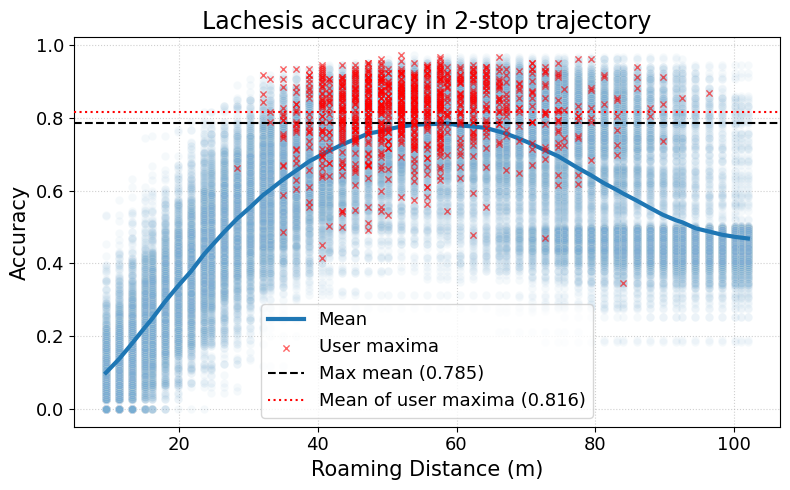

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_vs_param(
    ax=ax,
    data=results_df.loc[results_df.algorithm.str.startswith("lachesis")],
    x="delta_roam",
    y="recall",
    algo_param="delta_roam",
    show_max_mean_line=True,
    title="Lachesis accuracy in 2-stop trajectory",
    xlabel="Roaming Distance (m)",
    ylabel="Accuracy",
)

fig.tight_layout()
plt.savefig(f"figures/seq_delta_roam_acc.svg", bbox_inches='tight')
plt.savefig(f"figures/seq_delta_roam_acc.png", dpi=600, bbox_inches='tight')
plt.show()

## Sequential

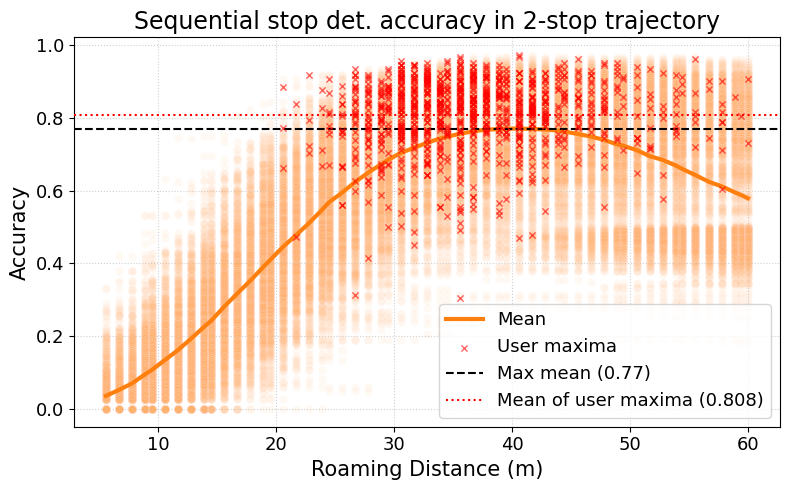

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_vs_param(
    ax=ax,
    data=results_df.loc[results_df.algorithm.str.startswith("sequential")],
    x="delta_roam",
    y="recall",
    algo_param="delta_roam",
    show_max_mean_line=True,
    title="Sequential stop det. accuracy in 2-stop trajectory",
    xlabel="Roaming Distance (m)",
    ylabel="Accuracy",
    color_idx=1
)

fig.tight_layout()
plt.savefig(f"figures/seq_delta_roam_acc.svg", bbox_inches='tight')
plt.savefig(f"figures/seq_delta_roam_acc.png", dpi=600, bbox_inches='tight')
plt.show()

## Combined

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: seqscan
plot_metric_vs_param(
    ax=axes[0],
    data=results_df.loc[results_df.algorithm.str.startswith("lachesis")],
    x="delta_roam",
    y="recall",
    algo_param="delta_roam",
    show_max_mean_line=True,
    title="Lachesis accuracy in 2-stop trajectory",
    xlabel="Roaming Distance (m)",
    ylabel="Accuracy",
)

# Right: st_dbscan
plot_metric_vs_param(
    ax=axes[1],
    data=results_df.loc[results_df.algorithm.str.startswith("sequential")],
    x="delta_roam",
    y="recall",
    algo_param="delta_roam",
    show_max_mean_line=True,
    title="Sequential stop det. accuracy in 2-stop trajectory",
    xlabel="Roaming Distance (m)",
    ylabel="Accuracy",
    color_idx=1
)

fig.tight_layout()
fig.savefig("figures/seq_delta_roam_acc.svg", bbox_inches="tight")
fig.savefig("figures/seq_delta_roam_acc.png", dpi=600, bbox_inches="tight")
plt.show()